In [36]:
# ============================================================
# IMPORTS NECESARIOS (Igual que en el Titanic)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

In [37]:
# ============================================================
# Carga de datos
# ============================================================

housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(f"Dataset cargado con {len(df)} filas.")


Dataset cargado con 20640 filas.


In [38]:
# ============================================================
# Exploración y comprensión del dataset
# ============================================================

print("\n--- Exploración inicial ---")
display(df.head())
display(df.info())
display(df.describe())
display(df.isnull().sum()) # valores nulos


--- Exploración inicial ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


None

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [39]:
# ============================================================
# División Train/Test
# ============================================================

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nConjunto de Entrenamiento: {len(X_train)} muestras")
print(f"Conjunto de Prueba: {len(X_test)} muestras")



Conjunto de Entrenamiento: 16512 muestras
Conjunto de Prueba: 4128 muestras


In [40]:
# ============================================================
# Preprocesamiento (Diseño del Pipeline)
# ============================================================

# Usamos solo las 8 variables numéricas disponibles en el DataFrame del usuario
numerical_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

# Imputación y Escalado para NUMÉRICAS
num_imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

# ColumnTransformer actualizado: solo el pipeline numérico
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', num_imputer), ('scaler', scaler)]), numerical_features)
    ],
    remainder='passthrough'
)

In [41]:
# ============================================================
# Construcción y Entrenamiento del modelo de Regresión Lineal base
# ============================================================

model = LinearRegression()
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model)
])

full_pipeline.fit(X_train, y_train)

# Predicción en los conjuntos
y_pred = full_pipeline.predict(X_test)
y_train_pred = full_pipeline.predict(X_train)

In [42]:
# ============================================================
# Evaluación del modelo (Métricas y CV)
# ============================================================

# Métricas en TEST (Lineal Base)
r2_test_base = r2_score(y_test, y_pred)
rmse_test_base = np.sqrt(mean_squared_error(y_test, y_pred))
print("\nMétricas en TEST (Lineal Base) \n")
print(f"R-cuadrado (R^2): {r2_test_base:.3f}")
print(f"RMSE: {rmse_test_base:.3f}")


--- 6. Métricas en TEST (Lineal Base) ---
R-cuadrado (R^2): 0.576
RMSE: 0.746



Generando Gráficas de Residuos ---


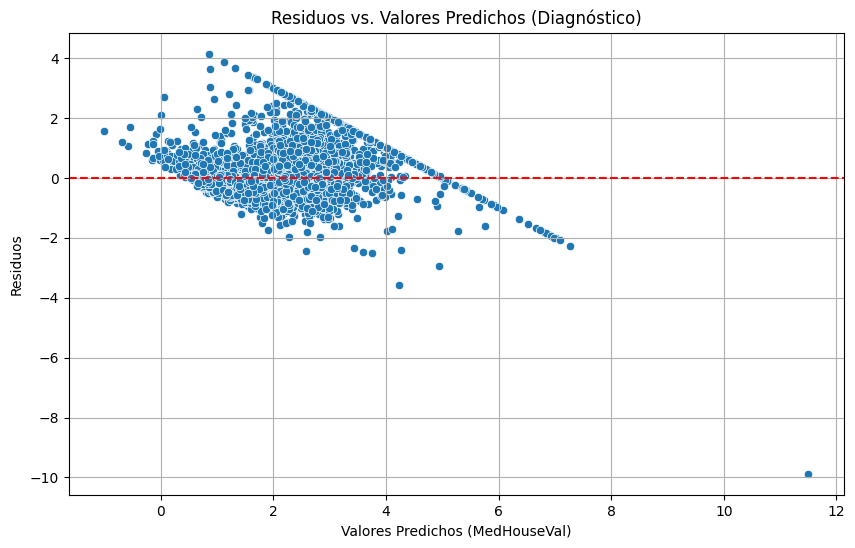

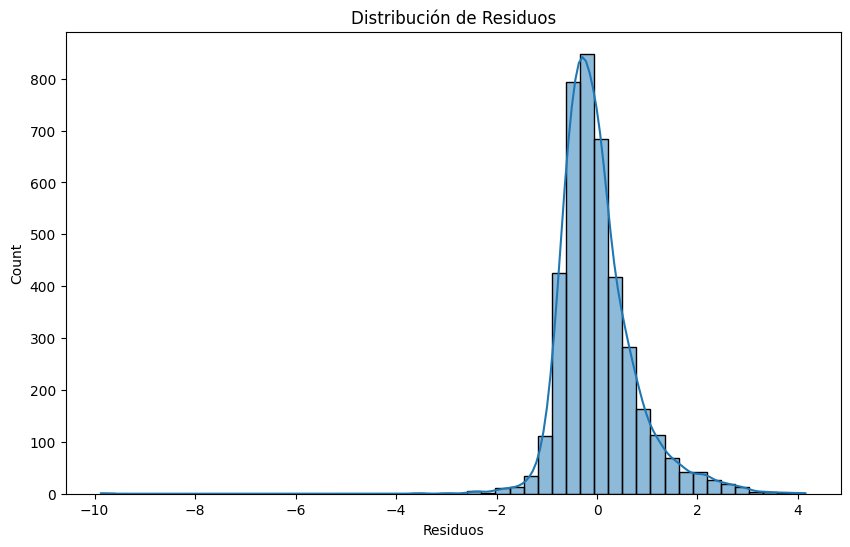

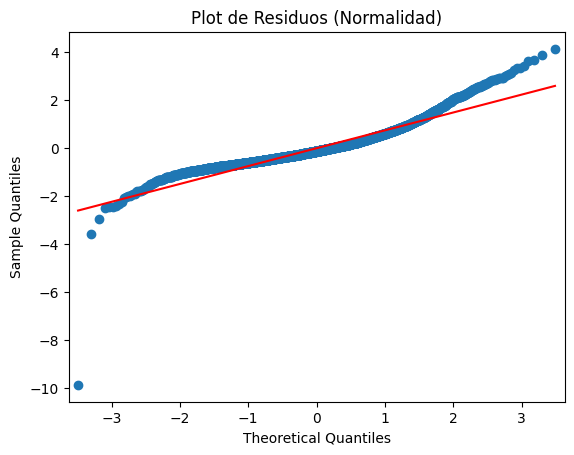

In [43]:
# ============================================================
# Diagnóstico de supuestos y análisis de residuos (GRÁFICAS)
# ============================================================
residuals = y_test - y_pred
predicted_values = y_pred
print("\nGenerando Gráficas de Residuos \n")

# Residuos vs. Predicciones
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predicted_values, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Predichos (MedHouseVal)')
plt.ylabel('Residuos')
plt.title('Residuos vs. Valores Predichos (Diagnóstico)')
plt.grid(True)
plt.show()


# Histograma de Residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.xlabel('Residuos')
plt.title('Distribución de Residuos')
plt.show()

# Q-Q Plot de Residuos
sm.qqplot(residuals, line='s')
plt.title('Plot de Residuos (Normalidad)')
plt.show()

In [45]:
# ============================================================
# Regularización y Selección de Modelo
# ============================================================

ridge_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(random_state=42))])
lasso_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Lasso(random_state=42, max_iter=2000))])

param_grid = {'regressor__alpha': np.logspace(-3, 1, 15)}

# GridSearchCV para Ridge
grid_search_ridge = GridSearchCV(ridge_pipe, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_ridge.fit(X_train, y_train)
best_ridge = grid_search_ridge.best_estimator_
best_alpha_ridge = grid_search_ridge.best_params_['regressor__alpha']

# GridSearchCV para Lasso
grid_search_lasso = GridSearchCV(lasso_pipe, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_lasso.fit(X_train, y_train)
best_lasso = grid_search_lasso.best_estimator_
best_alpha_lasso = grid_search_lasso.best_params_['regressor__alpha']

# Evaluación Final en TEST (Comparación)
y_pred_ridge = best_ridge.predict(X_test)
y_pred_lasso = best_lasso.predict(X_test)

rmse_ridge_test = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge_test = r2_score(y_test, y_pred_ridge)

rmse_lasso_test = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso_test = r2_score(y_test, y_pred_lasso)

print("\nResultados en el conjunto de TEST (Comparación) \n")
print(f"Lineal Base: R^2={r2_test_base:.3f}, RMSE={rmse_test_base:.3f}")
print(f"Ridge (alpha={best_alpha_ridge:.3f}): R^2={r2_ridge_test:.3f}, RMSE={rmse_ridge_test:.3f}")
print(f"Lasso (alpha={best_alpha_lasso:.3f}): R^2={r2_lasso_test:.3f}, RMSE={rmse_lasso_test:.3f}")


Resultados en el conjunto de TEST (Comparación) ---
Lineal Base: R^2=0.576, RMSE=0.746
Ridge (alpha=0.001): R^2=0.576, RMSE=0.746
Lasso (alpha=0.001): R^2=0.577, RMSE=0.745


In [46]:
# ============================================================
# Interpretación del modelo
# ============================================================

ridge_model = best_ridge.named_steps['regressor']
feature_names = best_ridge.named_steps['preprocessor'].get_feature_names_out()

# Crear un DataFrame para la interpretación
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_model.coef_
})

# Renombrar las features para mayor claridad
coef_df['Feature'] = coef_df['Feature'].str.replace('num__', '')
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print("\nInterpretación de Coeficientes (Modelo Ridge Final) ---")
print(coef_df)


Interpretación de Coeficientes (Modelo Ridge Final) ---
      Feature  Coefficient
0      MedInc     0.854383
3   AveBedrms     0.339259
1    HouseAge     0.122546
4  Population    -0.002308
5    AveOccup    -0.040829
2    AveRooms    -0.294410
7   Longitude    -0.869841
6    Latitude    -0.896928
